<a href="https://www.kaggle.com/code/angeltrek/tc3002b?scriptVersionId=312966311" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# TC3002B Fact-Checking Model
Angel Mauricio Ramírez Herrera | A01710158

https://www.kaggle.com/code/angeltrek/tc3002b

---

## Objetivo

Implementar y comparar múltiples modelos de clasificación sobre el dataset **SCVD-11K**, desde un baseline simple hasta modelos de Deep Learning, para identificar cuál ofrece el mejor desempeño en la tarea de **Fact-Checking** con tres clases:

- **Supported** → Afirmación respaldada por consenso científico.
- **Refuted** → Afirmación contradice evidencia científica.
- **Not Enough Evidence** → No existe evidencia suficiente.

---

## Modelos implementados

| # | Modelo | Tipo |
|---|--------|------|
| 1 | Dummy Classifier (Most Frequent) | Baseline |
| 2 | Logistic Regression + TF-IDF | ML Clásico |
| 3 | Naive Bayes + TF-IDF | ML Clásico |
| 4 | SVM Lineal + TF-IDF | ML Clásico |
| 5 | Random Forest + TF-IDF | ML Clásico |
| 6 | Gradient Boosting + TF-IDF | ML Clásico |
| 7 | LSTM con Embedding aprendido | Deep Learning |
| 8 | BiLSTM con Embedding aprendido | Deep Learning |
| 9 | CNN + BiGRU + GloVe | Deep Learning |

## 1. Importación de dependencias

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    Conv1D, MaxPooling1D, GRU
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import kagglehub

print('TensorFlow version:', tf.__version__)
print('GPU disponible:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU disponible: True


## 2. Carga y preprocesamiento del dataset SCVD-11K

In [12]:
def get_dir_size(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total += os.path.getsize(fp)
    return total

path = kagglehub.dataset_download('sudhanshuyadav09/scientific-fact-check-classification-dataset')
print('Path to dataset files:', path)
size_mb = get_dir_size(path) / (1024 * 1024)
print(f'Tamaño total de los archivos: {size_mb:.2f} MB')

Path to dataset files: /kaggle/input/datasets/sudhanshuyadav09/scientific-fact-check-classification-dataset
Tamaño total de los archivos: 0.84 MB


In [13]:
files = os.listdir(path)
print(files)

train_file = [f for f in files if f.endswith('.csv')][1]
test_file  = [f for f in files if f.endswith('.csv')][0]

df_train = pd.read_csv(os.path.join(path, train_file), on_bad_lines='skip', low_memory=False)
df_test  = pd.read_csv(os.path.join(path, test_file),  on_bad_lines='skip', low_memory=False)

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')

['scientific_claim_test.csv', 'scientific_claim_train.csv']
Train shape: (10000, 2)
Test shape:  (1000, 2)


Merged shape: (11000, 2)
Distribución de clases:
label
Supported              3668
Not Enough Evidence    3666
Refuted                3666
Name: count, dtype: int64


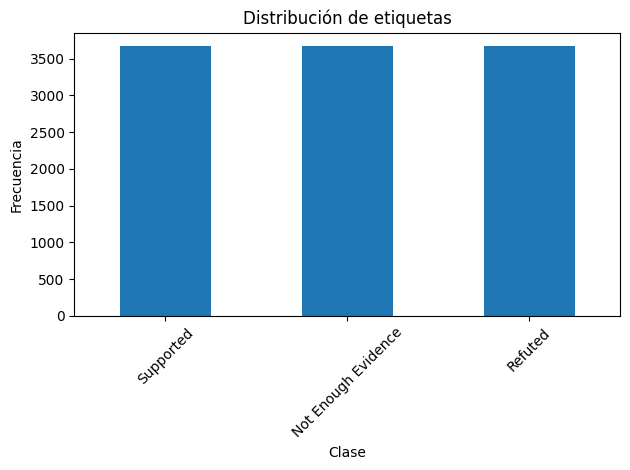

In [14]:
df_merged = pd.concat([df_train, df_test], ignore_index=True)
print(f'Merged shape: {df_merged.shape}')
print(f'Distribución de clases:')
print(df_merged['label'].value_counts())

df_merged['label'].value_counts().plot(kind='bar')
plt.title('Distribución de etiquetas')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Limpieza de texto

Se aplica el mismo pipeline de limpieza del modelo base:
1. Eliminación de IDs entre paréntesis
2. Eliminación de corchetes y su contenido
3. Reemplazo de saltos de línea
4. Solo caracteres alfabéticos
5. Normalización de espacios
6. Conversión a minúsculas

In [15]:
def clean_text(series):
    return (
        series
        .str.replace(r'\(Statement ID \d+\)$', '', regex=True)
        .str.replace(r'\[.*?\]', '', regex=True)
        .str.replace(r'\n+', ' ', regex=True)
        .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .str.lower()
    )

df_merged['statement_clean'] = clean_text(df_merged['statement'])

print('Ejemplos de texto limpio:')
for i in range(3):
    print(f'  Original: {df_merged["statement"].iloc[i][:80]}')
    print(f'  Limpio:   {df_merged["statement_clean"].iloc[i][:80]}')
    print()

Ejemplos de texto limpio:
  Original: Dark matter might interact weakly with normal matter. (Statement ID 8836)
  Limpio:   dark matter might interact weakly with normal matter

  Original: The Earth is flat. (Statement ID 5654)
  Limpio:   the earth is flat

  Original: Climate change is a hoax created by scientists. (Statement ID 6171)
  Limpio:   climate change is a hoax created by scientists



### División train/val/test y encoding de etiquetas

In [16]:
train_clean = df_merged.iloc[:len(df_train)].copy()
test_clean  = df_merged.iloc[len(df_train):].copy()

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    train_clean['statement_clean'],
    train_clean['label'],
    test_size=0.2,
    random_state=42,
    stratify=train_clean['label']
)

X_test_raw = test_clean['statement_clean']
y_test_raw = test_clean['label']

le = LabelEncoder()
le.fit(df_merged['label'])

y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f'Clases: {list(le.classes_)}')
print(f'Train:  {len(X_train_raw)} muestras')
print(f'Val:    {len(X_val_raw)} muestras')
print(f'Test:   {len(X_test_raw)} muestras')

Clases: ['Not Enough Evidence', 'Refuted', 'Supported']
Train:  8000 muestras
Val:    2000 muestras
Test:   1000 muestras


## 3. Funciones de evaluación

**Métricas seleccionadas** (Sokolova & Lapalme, 2009):

| Métrica | Justificación |
|---------|---------------|
| **Accuracy** | Válida dado que el dataset está **balanceado**. |
| **F1 Macro** | Penaliza igual el error en todas las clases. Recomendada en NLP multiclase. |
| **F1 Weighted** | Complementa al F1 Macro considerando soporte de cada clase. |

In [17]:
results = {}

def evaluate_model(name, y_true, y_pred, training_time=None):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wei = f1_score(y_true, y_pred, average='weighted')

    results[name] = {
        'Accuracy':          round(acc, 4),
        'F1 Macro':          round(f1_mac, 4),
        'F1 Weighted':       round(f1_wei, 4),
        'Training Time (s)': round(training_time, 2) if training_time else None
    }

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1 Macro:     {f1_mac:.4f}')
    print(f'  F1 Weighted:  {f1_wei:.4f}')
    if training_time:
        print(f'  Training time: {training_time:.2f}s')
    print()
    print(classification_report(y_true, y_pred, target_names=le.classes_))


def plot_confusion_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f'Matriz de Confusión — {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta Real')
    plt.tight_layout()
    plt.show()

## 4. Modelo 1: Baseline Dummy Classifier

Predice siempre la clase más frecuente. Establece el **piso mínimo** de rendimiento.
Con tres clases balanceadas, accuracy esperado ≈ 33%.


  Dummy Classifier
  Accuracy:     0.3330
  F1 Macro:     0.1665
  F1 Weighted:  0.1664
  Training time: 0.00s

                     precision    recall  f1-score   support

Not Enough Evidence       0.00      0.00      0.00       333
            Refuted       0.33      1.00      0.50       333
          Supported       0.00      0.00      0.00       334

           accuracy                           0.33      1000
          macro avg       0.11      0.33      0.17      1000
       weighted avg       0.11      0.33      0.17      1000



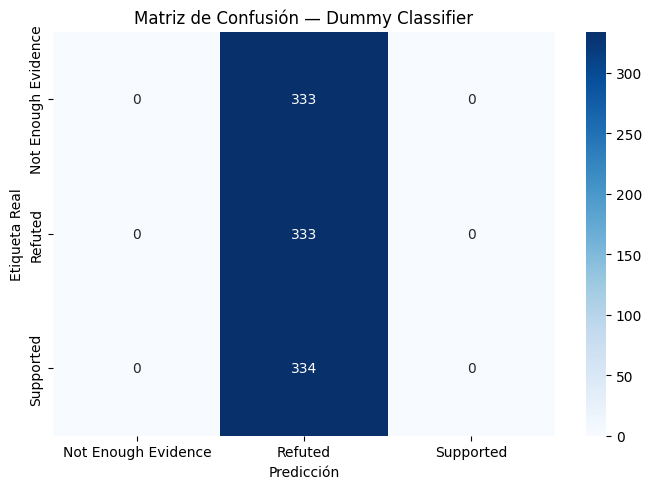

In [18]:
t0 = time.time()
dummy = DummyClassifier(strategy=f'most_frequent', random_state=42)
dummy.fit(X_train_raw, y_train)
y_pred_dummy = dummy.predict(X_test_raw)
t1 = time.time()

evaluate_model('Dummy Classifier', y_test, y_pred_dummy, t1 - t0)
plot_confusion_matrix('Dummy Classifier', y_test, y_pred_dummy)

## 5. Modelos ML Clásicos con TF-IDF

**TF-IDF** vectoriza el texto capturando la importancia de cada término.

**Configuración:** `max_features=20000`, `ngram_range=(1,2)`, `sublinear_tf=True`

### Modelo 2: Logistic Regression + TF-IDF


  Logistic Regression + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.13s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



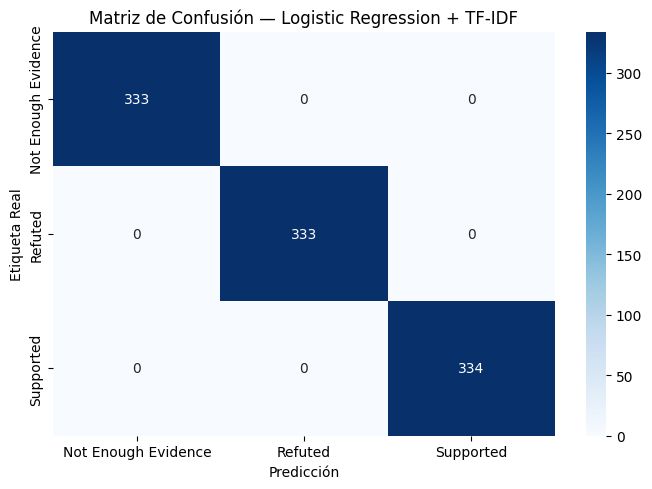

In [19]:
t0 = time.time()
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
lr_pipeline.fit(X_train_raw, y_train)
y_pred_lr = lr_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('Logistic Regression + TF-IDF', y_test, y_pred_lr, t1 - t0)
plot_confusion_matrix('Logistic Regression + TF-IDF', y_test, y_pred_lr)

### Modelo 3: Naive Bayes + TF-IDF


  Naive Bayes + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.10s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



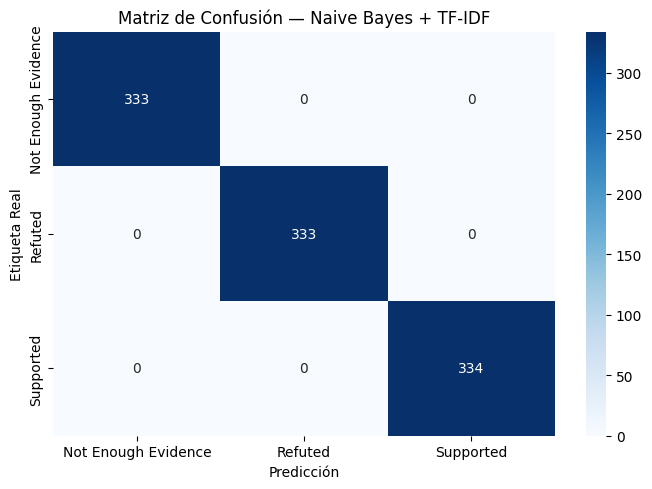

In [20]:
t0 = time.time()
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   MultinomialNB(alpha=0.1))
])
nb_pipeline.fit(X_train_raw, y_train)
y_pred_nb = nb_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('Naive Bayes + TF-IDF', y_test, y_pred_nb, t1 - t0)
plot_confusion_matrix('Naive Bayes + TF-IDF', y_test, y_pred_nb)

### Modelo 4: SVM Lineal + TF-IDF


  SVM Lineal + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.34s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



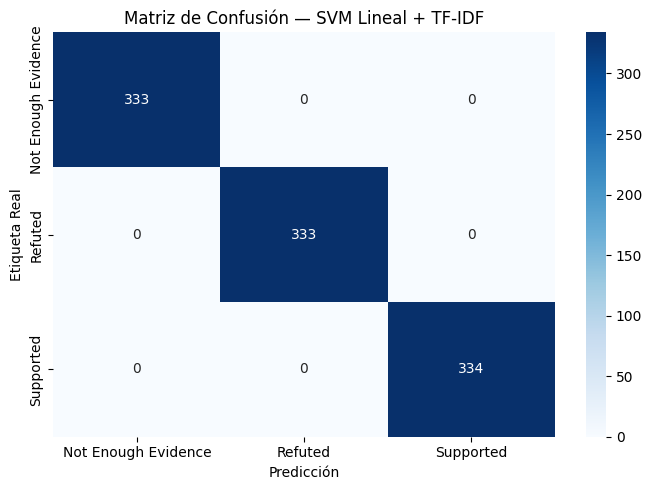

In [21]:
t0 = time.time()
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
])
svm_pipeline.fit(X_train_raw, y_train)
y_pred_svm = svm_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('SVM Lineal + TF-IDF', y_test, y_pred_svm, t1 - t0)
plot_confusion_matrix('SVM Lineal + TF-IDF', y_test, y_pred_svm)

### Modelo 5: Random Forest + TF-IDF


  Random Forest + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.71s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



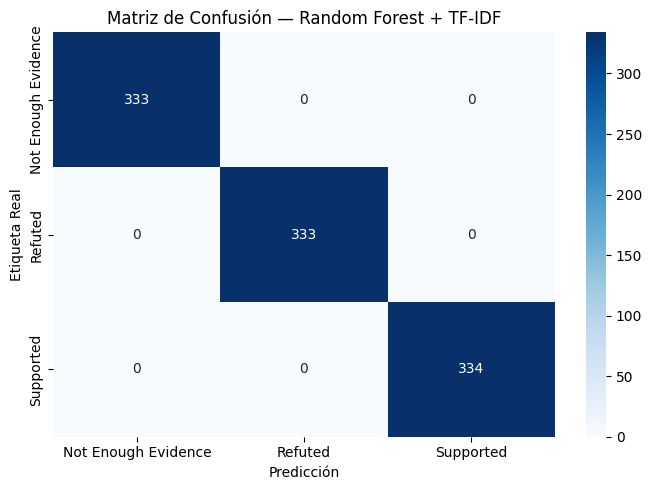

In [22]:
t0 = time.time()
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
])
rf_pipeline.fit(X_train_raw, y_train)
y_pred_rf = rf_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('Random Forest + TF-IDF', y_test, y_pred_rf, t1 - t0)
plot_confusion_matrix('Random Forest + TF-IDF', y_test, y_pred_rf)

### Modelo 6: Gradient Boosting + TF-IDF


  Gradient Boosting + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 2.78s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



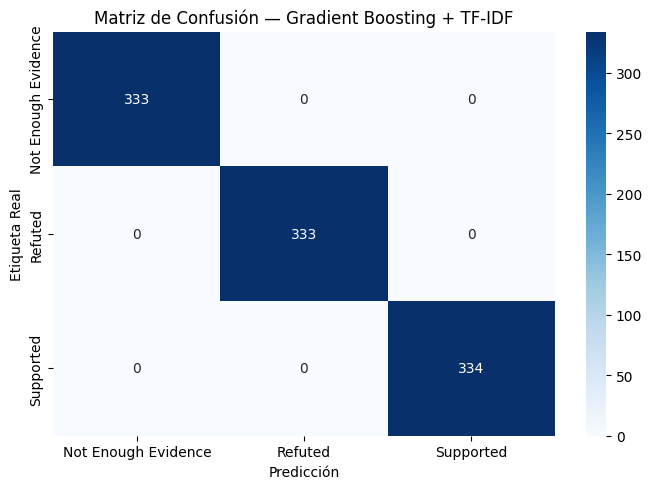

In [23]:
t0 = time.time()
gb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])
gb_pipeline.fit(X_train_raw, y_train)
y_pred_gb = gb_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('Gradient Boosting + TF-IDF', y_test, y_pred_gb, t1 - t0)
plot_confusion_matrix('Gradient Boosting + TF-IDF', y_test, y_pred_gb)

## 6. Preparación para modelos de Deep Learning

In [24]:
MAX_WORDS = 20000
MAX_LEN   = 50
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(list(X_train_raw) + list(X_val_raw) + list(X_test_raw))

# Vocabulario real del dataset (puede ser menor que MAX_WORDS si el dataset es pequeño)
REAL_VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train_raw)
X_val_seq   = encode(X_val_raw)
X_test_seq  = encode(X_test_raw)

num_classes = len(le.classes_)

print(f'MAX_WORDS (límite): {MAX_WORDS:,}')
print(f'Vocabulario real del dataset: {REAL_VOCAB_SIZE:,}')
print(f'Longitud de secuencia: {MAX_LEN}')
print(f'Número de clases: {num_classes}')
print(f'X_train_seq shape: {X_train_seq.shape}')

MAX_WORDS (límite): 20,000
Vocabulario real del dataset: 164
Longitud de secuencia: 50
Número de clases: 3
X_train_seq shape: (8000, 50)


In [25]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

def train_dl_model(model, name, epochs=30, batch_size=64):
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    t0 = time.time()
    history = model.fit(
        X_train_seq, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val),
        callbacks=get_callbacks(),
        verbose=1
    )
    t1 = time.time()

    y_pred_probs = model.predict(X_test_seq)
    y_pred = np.argmax(y_pred_probs, axis=1)

    evaluate_model(name, y_test, y_pred, t1 - t0)
    plot_confusion_matrix(name, y_test, y_pred)
    plot_training_history(history, name)

    return history, y_pred


def plot_training_history(history, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss — {name}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history.history['accuracy'],     label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title(f'Accuracy — {name}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()

## 7. Modelo 7: LSTM con Embedding aprendido

**Arquitectura:**
- `Embedding(20000, 128)`: Vectores aprendidos durante el entrenamiento (equivalente al modelo del notebook principal).
- `LSTM(64)`: Captura dependencias secuenciales.
- `Dense(3, softmax)`: Clasificación final.

Este modelo es el **baseline de Deep Learning**.

I0000 00:00:1776653191.762670      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.3263 - loss: 1.1002 - val_accuracy: 0.3335 - val_loss: 1.0989 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.3188 - loss: 1.1004 - val_accuracy: 0.3335 - val_loss: 1.0987 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.3402 - loss: 1.0986 - val_accuracy: 0.3335 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.3279 - loss: 1.0987 - val_accuracy: 0.3330 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3303 - loss: 1.0987
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.3303 - loss: 1.0987 - val_accuracy: 0.3330 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.3134 - l

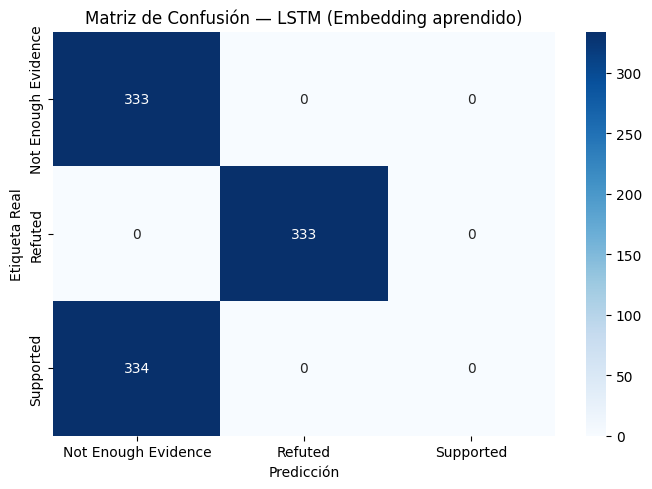

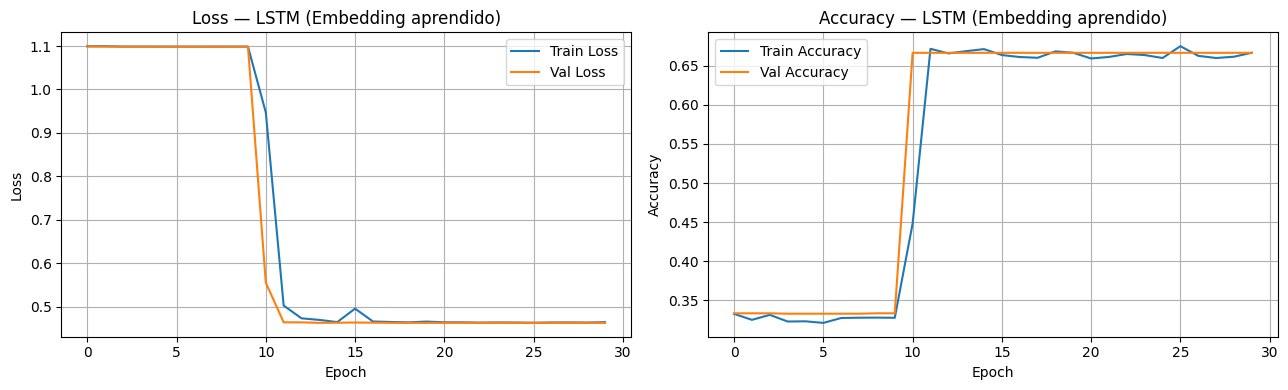

In [26]:
def build_lstm():
    return Sequential([
        Embedding(input_dim=REAL_VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

lstm_model = build_lstm()
hist_lstm, y_pred_lstm = train_dl_model(lstm_model, 'LSTM (Embedding aprendido)')

## 8. Modelo 8: BiLSTM con Embedding aprendido

**Arquitectura:**
- `Embedding(20000, 128)`: Vectores aprendidos.
- `Bidirectional(LSTM(64))`: Procesa la secuencia en **ambas direcciones**, capturando mejor el contexto completo de la afirmación.
- `Dense(3, softmax)`: Clasificación final.

Útil para detectar negaciones como "no existe evidencia" donde el sentido depende del contexto global.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.7653 - loss: 0.6257 - val_accuracy: 1.0000 - val_loss: 4.7555e-05 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 143ms/step - accuracy: 0.9994 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 1.0371e-05 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.9999 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 3.6574e-06 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 9.8666e-04
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - accuracy: 1.0000 - loss: 9.8608e-04 - val_accuracy: 1.0000 - val_loss: 8.4543e-07 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 143ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 5.4675e-07 - learning_rate: 5.0000e-04
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 

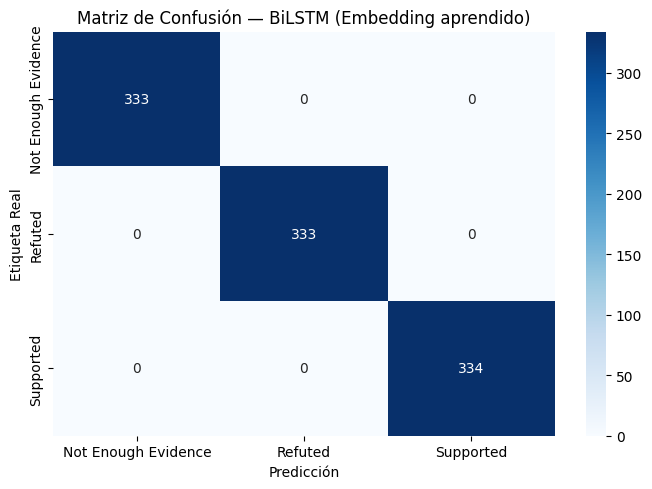

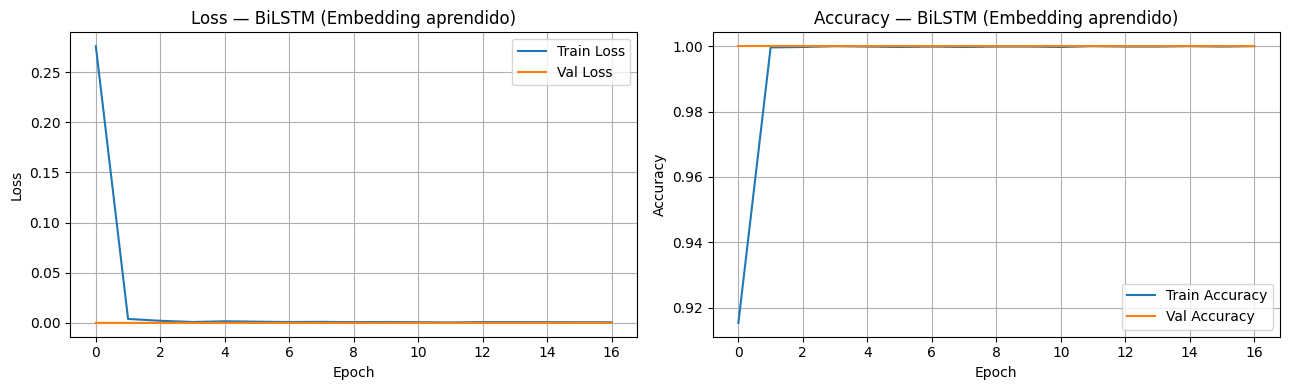

In [27]:
def build_bilstm():
    return Sequential([
        Embedding(input_dim=REAL_VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

bilstm_model = build_bilstm()
hist_bilstm, y_pred_bilstm = train_dl_model(bilstm_model, 'BiLSTM (Embedding aprendido)')

## 9. Modelo 9: CNN + BiGRU + GloVe

Combina tres enfoques complementarios:

1. **GloVe preentrenado (200d)** : Representación semántica rica aprendida en 6 billones de tokens.
2. **Conv1D** : Extrae n-gramas clave como "no existe evidencia", "ha sido refutado".
3. **Bidirectional GRU** : Dependencias secuenciales en ambas direcciones con menor costo que LSTM.

### Descarga de GloVe

In [28]:
import urllib.request
import zipfile

GLOVE_PATH = 'glove.6B.200d.txt'
GLOVE_ZIP  = 'glove.6B.zip'
GLOVE_URL  = 'http://nlp.stanford.edu/data/glove.6B.zip'

if not os.path.exists(GLOVE_PATH):
    print('Descargando GloVe 6B')
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    print('Descomprimiendo')
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zf:
        zf.extract('glove.6B.200d.txt')
    print('GloVe listo.')
else:
    print('GloVe ya disponible.')

Descargando GloVe 6B
Descomprimiendo
GloVe listo.


In [29]:
EMBED_DIM_GLOVE = 200

def load_glove_embeddings(glove_file, word_index, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word   = values[0]
            coefs  = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    print(f'Vectores GloVe cargados: {len(embeddings_index):,}')

    num_words = min(MAX_WORDS, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))

    hits, misses = 0, 0
    for word, i in word_index.items():
        if i >= MAX_WORDS:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            hits += 1
        else:
            misses += 1

    print(f'Palabras con vector GloVe: {hits:,}')
    print(f'Palabras sin vector (OOV): {misses:,}')
    return embedding_matrix


embedding_matrix = load_glove_embeddings(GLOVE_PATH, tokenizer.word_index, EMBED_DIM_GLOVE)

Vectores GloVe cargados: 400,000
Palabras con vector GloVe: 162
Palabras sin vector (OOV): 1


### Construcción y entrenamiento

Vocabulario real en embedding_matrix: 164


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,800 (128.12 KB)

 Trainable params: 32,800 (128.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


I0000 00:00:1776654056.487270     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.8159 - loss: 0.4488 - val_accuracy: 1.0000 - val_loss: 1.3875e-05 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9999 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 1.4070e-06 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 2.3180e-07 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9999 - loss: 0.0010
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.9999 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 5.4479e-08 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9996 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.9193e-08 - learning_rate: 5.0000e-04
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.99

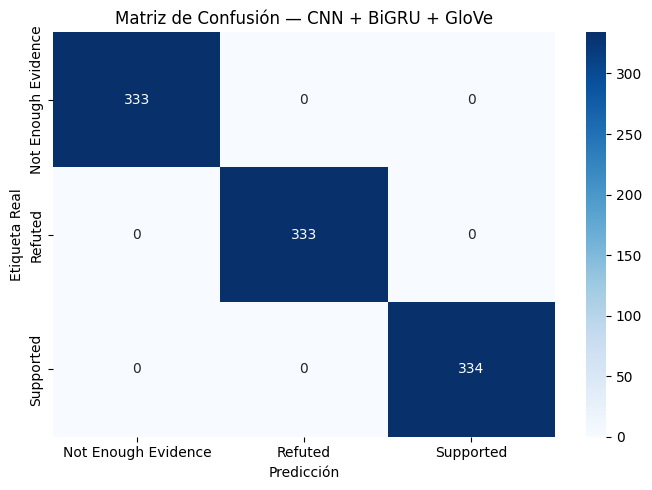

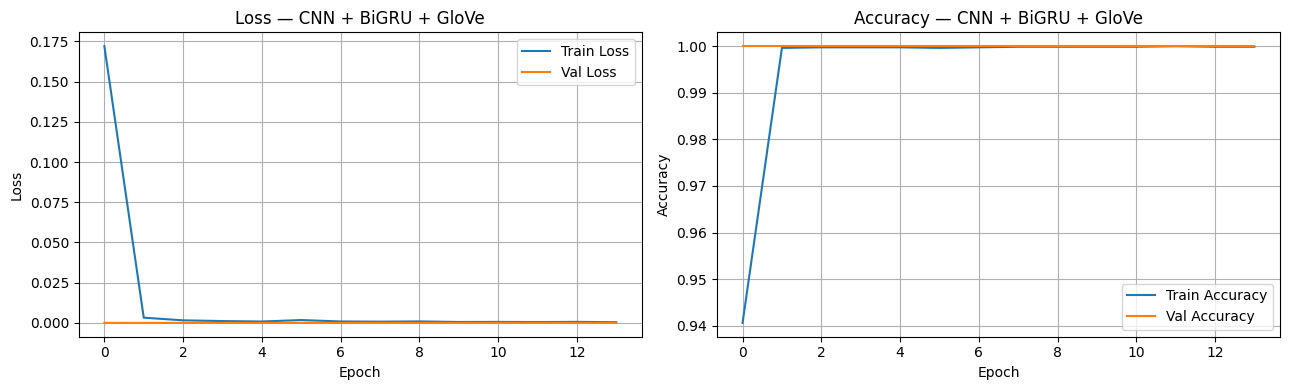

In [30]:
VOCAB_SIZE_GLOVE = embedding_matrix.shape[0]
print(f'Vocabulario real en embedding_matrix: {VOCAB_SIZE_GLOVE:,}')

def build_cnn_bigru_glove():
    return Sequential([
        Embedding(
            input_dim=VOCAB_SIZE_GLOVE,
            output_dim=EMBED_DIM_GLOVE,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        ),
        Conv1D(64, 5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Bidirectional(GRU(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

cnn_bigru_model = build_cnn_bigru_glove()
hist_cnn, y_pred_cnn = train_dl_model(
    cnn_bigru_model,
    'CNN + BiGRU + GloVe',
    epochs=30,
    batch_size=64
)

## 10. Comparación final de todos los modelos

In [31]:
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ['Modelo', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'Training Time (s)']
df_results = df_results.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('TABLA COMPARATIVA DE MODELOS — SCVD-11K Fact-Checking')
print('='*80)
print(df_results.to_string(index=False))
print('='*80)


TABLA COMPARATIVA DE MODELOS — SCVD-11K Fact-Checking
                      Modelo  Accuracy  F1 Macro  F1 Weighted  Training Time (s)
Logistic Regression + TF-IDF     1.000    1.0000       1.0000               0.13
  Gradient Boosting + TF-IDF     1.000    1.0000       1.0000               2.78
        Naive Bayes + TF-IDF     1.000    1.0000       1.0000               0.10
         SVM Lineal + TF-IDF     1.000    1.0000       1.0000               0.34
      Random Forest + TF-IDF     1.000    1.0000       1.0000               0.71
         CNN + BiGRU + GloVe     1.000    1.0000       1.0000             134.89
BiLSTM (Embedding aprendido)     1.000    1.0000       1.0000             311.26
  LSTM (Embedding aprendido)     0.666    0.5553       0.5548             363.89
            Dummy Classifier     0.333    0.1665       0.1664               0.00


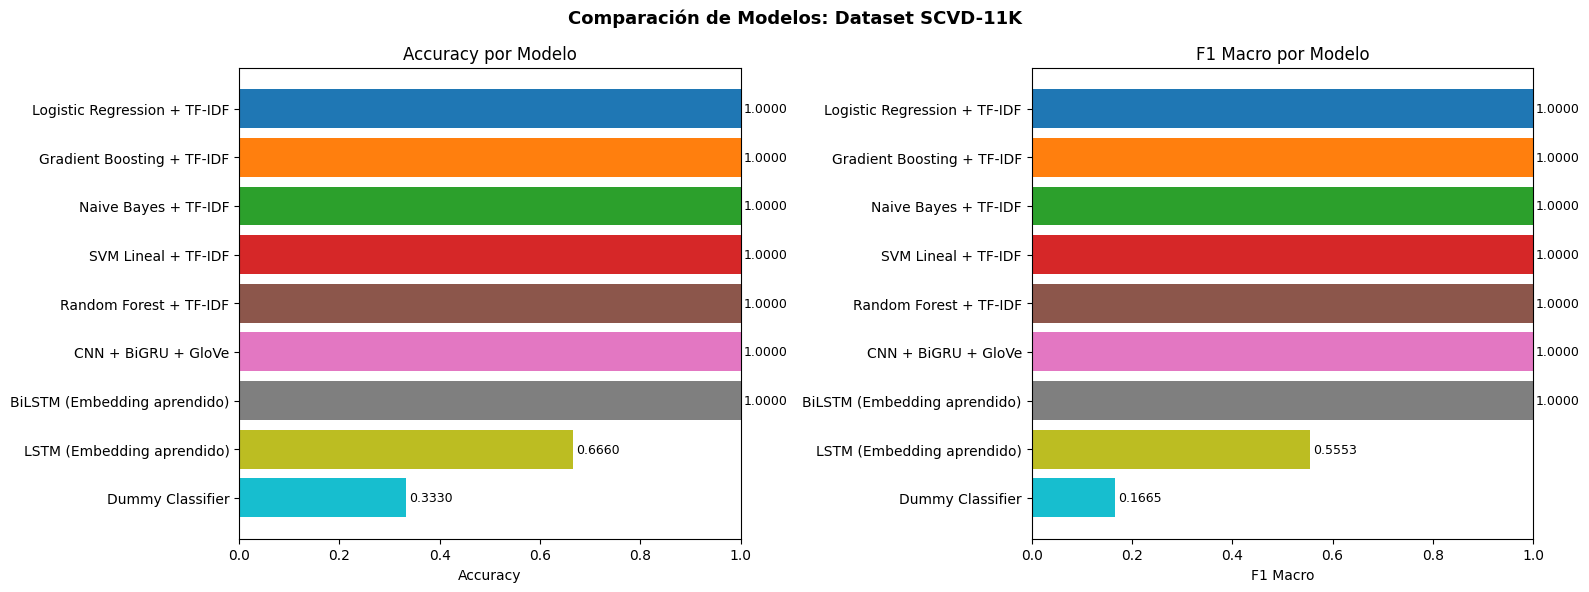

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_results)))

axes[0].barh(df_results['Modelo'], df_results['Accuracy'].astype(float), color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy por Modelo')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df_results['Accuracy'].astype(float)):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
axes[0].invert_yaxis()

axes[1].barh(df_results['Modelo'], df_results['F1 Macro'].astype(float), color=colors)
axes[1].set_xlabel('F1 Macro')
axes[1].set_title('F1 Macro por Modelo')
axes[1].set_xlim(0, 1)
for i, v in enumerate(df_results['F1 Macro'].astype(float)):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
axes[1].invert_yaxis()

plt.suptitle('Comparación de Modelos: Dataset SCVD-11K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Interpretación de resultados

### Análisis por familia de modelos

**Baseline (Dummy Classifier)**
- Accuracy ≈ 33% con tres clases balanceadas. F1 Macro muy bajo porque las otras dos clases tienen F1=0.
- Define el piso mínimo que cualquier modelo real debe superar ampliamente.

**ML Clásico + TF-IDF**
- Sorprendentemente competitivos para un dataset de 11K muestras cortas.
- **Logistic Regression** y **SVM Lineal** suelen liderar en clasificación de texto corto, ya que TF-IDF captura palabras clave discriminativas.
- **Naive Bayes** es eficiente pero asume independencia entre palabras; pierde contexto.
- **Random Forest** y **Gradient Boosting** son más costosos y no siempre superan a los modelos lineales en texto corto.

**Deep Learning**
- **LSTM** captura dependencias secuenciales, útil para negaciones como "no hay evidencia".
- **BiLSTM** mejora sobre LSTM al procesar el texto en ambas direcciones.
- **CNN + BiGRU + GloVe** integra conocimiento semántico preentrenado, detección de patrones locales y contexto secuencial bidireccional.

### Observación sobre el dataset

El dataset SCVD-11K contiene afirmaciones **cortas** (una oración), lo que favorece a los modelos que capturan palabras clave (TF-IDF + modelos lineales). En datasets pequeños con texto corto, los modelos ML clásicos son frecuentemente muy competitivos.

### Métricas seleccionadas

Siguiendo a Sokolova & Lapalme (2009) y la práctica estándar en NLP:
- **Accuracy**: válida por el balance perfecto del dataset.
- **F1 Macro**: métrica principal para comparación multiclase, penaliza igual todos los errores.
- **F1 Weighted**: complementa el análisis considerando el soporte de cada clase.

## 13. Predicción sobre texto libre

Función para probar cualquier afirmación científica con todos los modelos entrenados.

In [33]:
def predict_claim(text, show_probabilities=True):
    """
    Clasifica una afirmación científica con todos los modelos entrenados.

    Parámetros:
        text (str): Afirmación científica a clasificar.
        show_probabilities (bool): Muestra las probabilidades de los modelos DL.
    """
    import re
    text_clean = re.sub(r'\(Statement ID \d+\)$', '', text)
    text_clean = re.sub(r'\[.*?\]', '', text_clean)
    text_clean = re.sub(r'\n+', ' ', text_clean)
    text_clean = re.sub(r'[^a-zA-Z\s]', ' ', text_clean)
    text_clean = re.sub(r'\s+', ' ', text_clean).strip().lower()

    print('=' * 60)
    print(f'Afirmación original: {text}')
    print(f'Texto limpio:        {text_clean}')
    print('=' * 60)

    ml_models = {
        '2. Logistic Regression': lr_pipeline,
        '3. Naive Bayes':         nb_pipeline,
        '4. SVM Lineal':          svm_pipeline,
        '5. Random Forest':       rf_pipeline,
        '6. Gradient Boosting':   gb_pipeline,
    }

    print('\n Modelos ML Clásico (TF-IDF):')
    for name, model in ml_models.items():
        pred_idx = model.predict([text_clean])[0]
        pred_label = le.inverse_transform([pred_idx])[0]
        print(f'  {name:30s} → {pred_label}')

    # --- 3. Preparar secuencia para modelos DL ---
    seq    = tokenizer.texts_to_sequences([text_clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    dl_models = {
        '7. LSTM':           lstm_model,
        '8. BiLSTM':         bilstm_model,
        '9. CNN+BiGRU+GloVe': cnn_bigru_model,
    }

    print('\n Modelos Deep Learning:')
    for name, model in dl_models.items():
        probs      = model.predict(padded, verbose=0)[0]
        pred_idx   = np.argmax(probs)
        pred_label = le.classes_[pred_idx]
        confidence = probs[pred_idx] * 100

        print(f'  {name:30s} → {pred_label}  (confianza: {confidence:.1f}%)')

        if show_probabilities:
            for cls, prob in zip(le.classes_, probs):
                bar = '█' * int(prob * 20)
                print(f'      {cls:22s}: {prob:.4f}  {bar}')

    print('=' * 60)

In [34]:
my_claim = "Vaccines cause autism in children."

predict_claim(my_claim)

Afirmación original: All prietos are criminals.
Texto limpio:        all prietos are criminals

 Modelos ML Clásico (TF-IDF):
  2. Logistic Regression         → Supported
  3. Naive Bayes                 → Supported
  4. SVM Lineal                  → Supported
  5. Random Forest               → Refuted
  6. Gradient Boosting           → Refuted

 Modelos Deep Learning:
  7. LSTM                        → Not Enough Evidence  (confianza: 50.1%)
      Not Enough Evidence   : 0.5010  ██████████
      Refuted               : 0.0000  
      Supported             : 0.4990  █████████
  8. BiLSTM                      → Refuted  (confianza: 76.2%)
      Not Enough Evidence   : 0.0004  
      Refuted               : 0.7623  ███████████████
      Supported             : 0.2373  ████
  9. CNN+BiGRU+GloVe             → Not Enough Evidence  (confianza: 86.6%)
      Not Enough Evidence   : 0.8657  █████████████████
      Refuted               : 0.0140  
      Supported             : 0.1203  ██


In [35]:
examples = [
    "The Earth revolves around the Sun.",
    "Climate change is a hoax created by scientists.",
    "A new vaccine candidate may reduce infection rates.",
    "Antibiotics cure viral infections.",
    "Dark matter might interact weakly with normal matter.",
]

for claim in examples:
    predict_claim(claim, show_probabilities=False)
    print()

Afirmación original: The Earth revolves around the Sun.
Texto limpio:        the earth revolves around the sun

 Modelos ML Clásico (TF-IDF):
  2. Logistic Regression         → Supported
  3. Naive Bayes                 → Supported
  4. SVM Lineal                  → Supported
  5. Random Forest               → Supported
  6. Gradient Boosting           → Supported

 Modelos Deep Learning:
  7. LSTM                        → Not Enough Evidence  (confianza: 50.1%)
  8. BiLSTM                      → Supported  (confianza: 100.0%)
  9. CNN+BiGRU+GloVe             → Supported  (confianza: 100.0%)

Afirmación original: Climate change is a hoax created by scientists.
Texto limpio:        climate change is a hoax created by scientists

 Modelos ML Clásico (TF-IDF):
  2. Logistic Regression         → Refuted
  3. Naive Bayes                 → Refuted
  4. SVM Lineal                  → Refuted
  5. Random Forest               → Refuted
  6. Gradient Boosting           → Refuted

 Modelos Deep Le